# 0. Overview
- Dataset: Boston house price
- Task: Regression
- Model: Multiple Linear Model
- Loss function: MSE

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Data Collection

In [33]:
from sklearn import datasets
X, y = datasets.fetch_openml('boston', return_X_y=True)

/opt/homebrew/anaconda3/envs/ds/lib/python3.9/site-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name boston exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=531
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=853

  warn(warning_msg)


# 2. Data Preprocessing

## General

In [34]:
df = pd.concat([X, y], axis=1)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


## Missing values

In [36]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


## Outlier

In [37]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


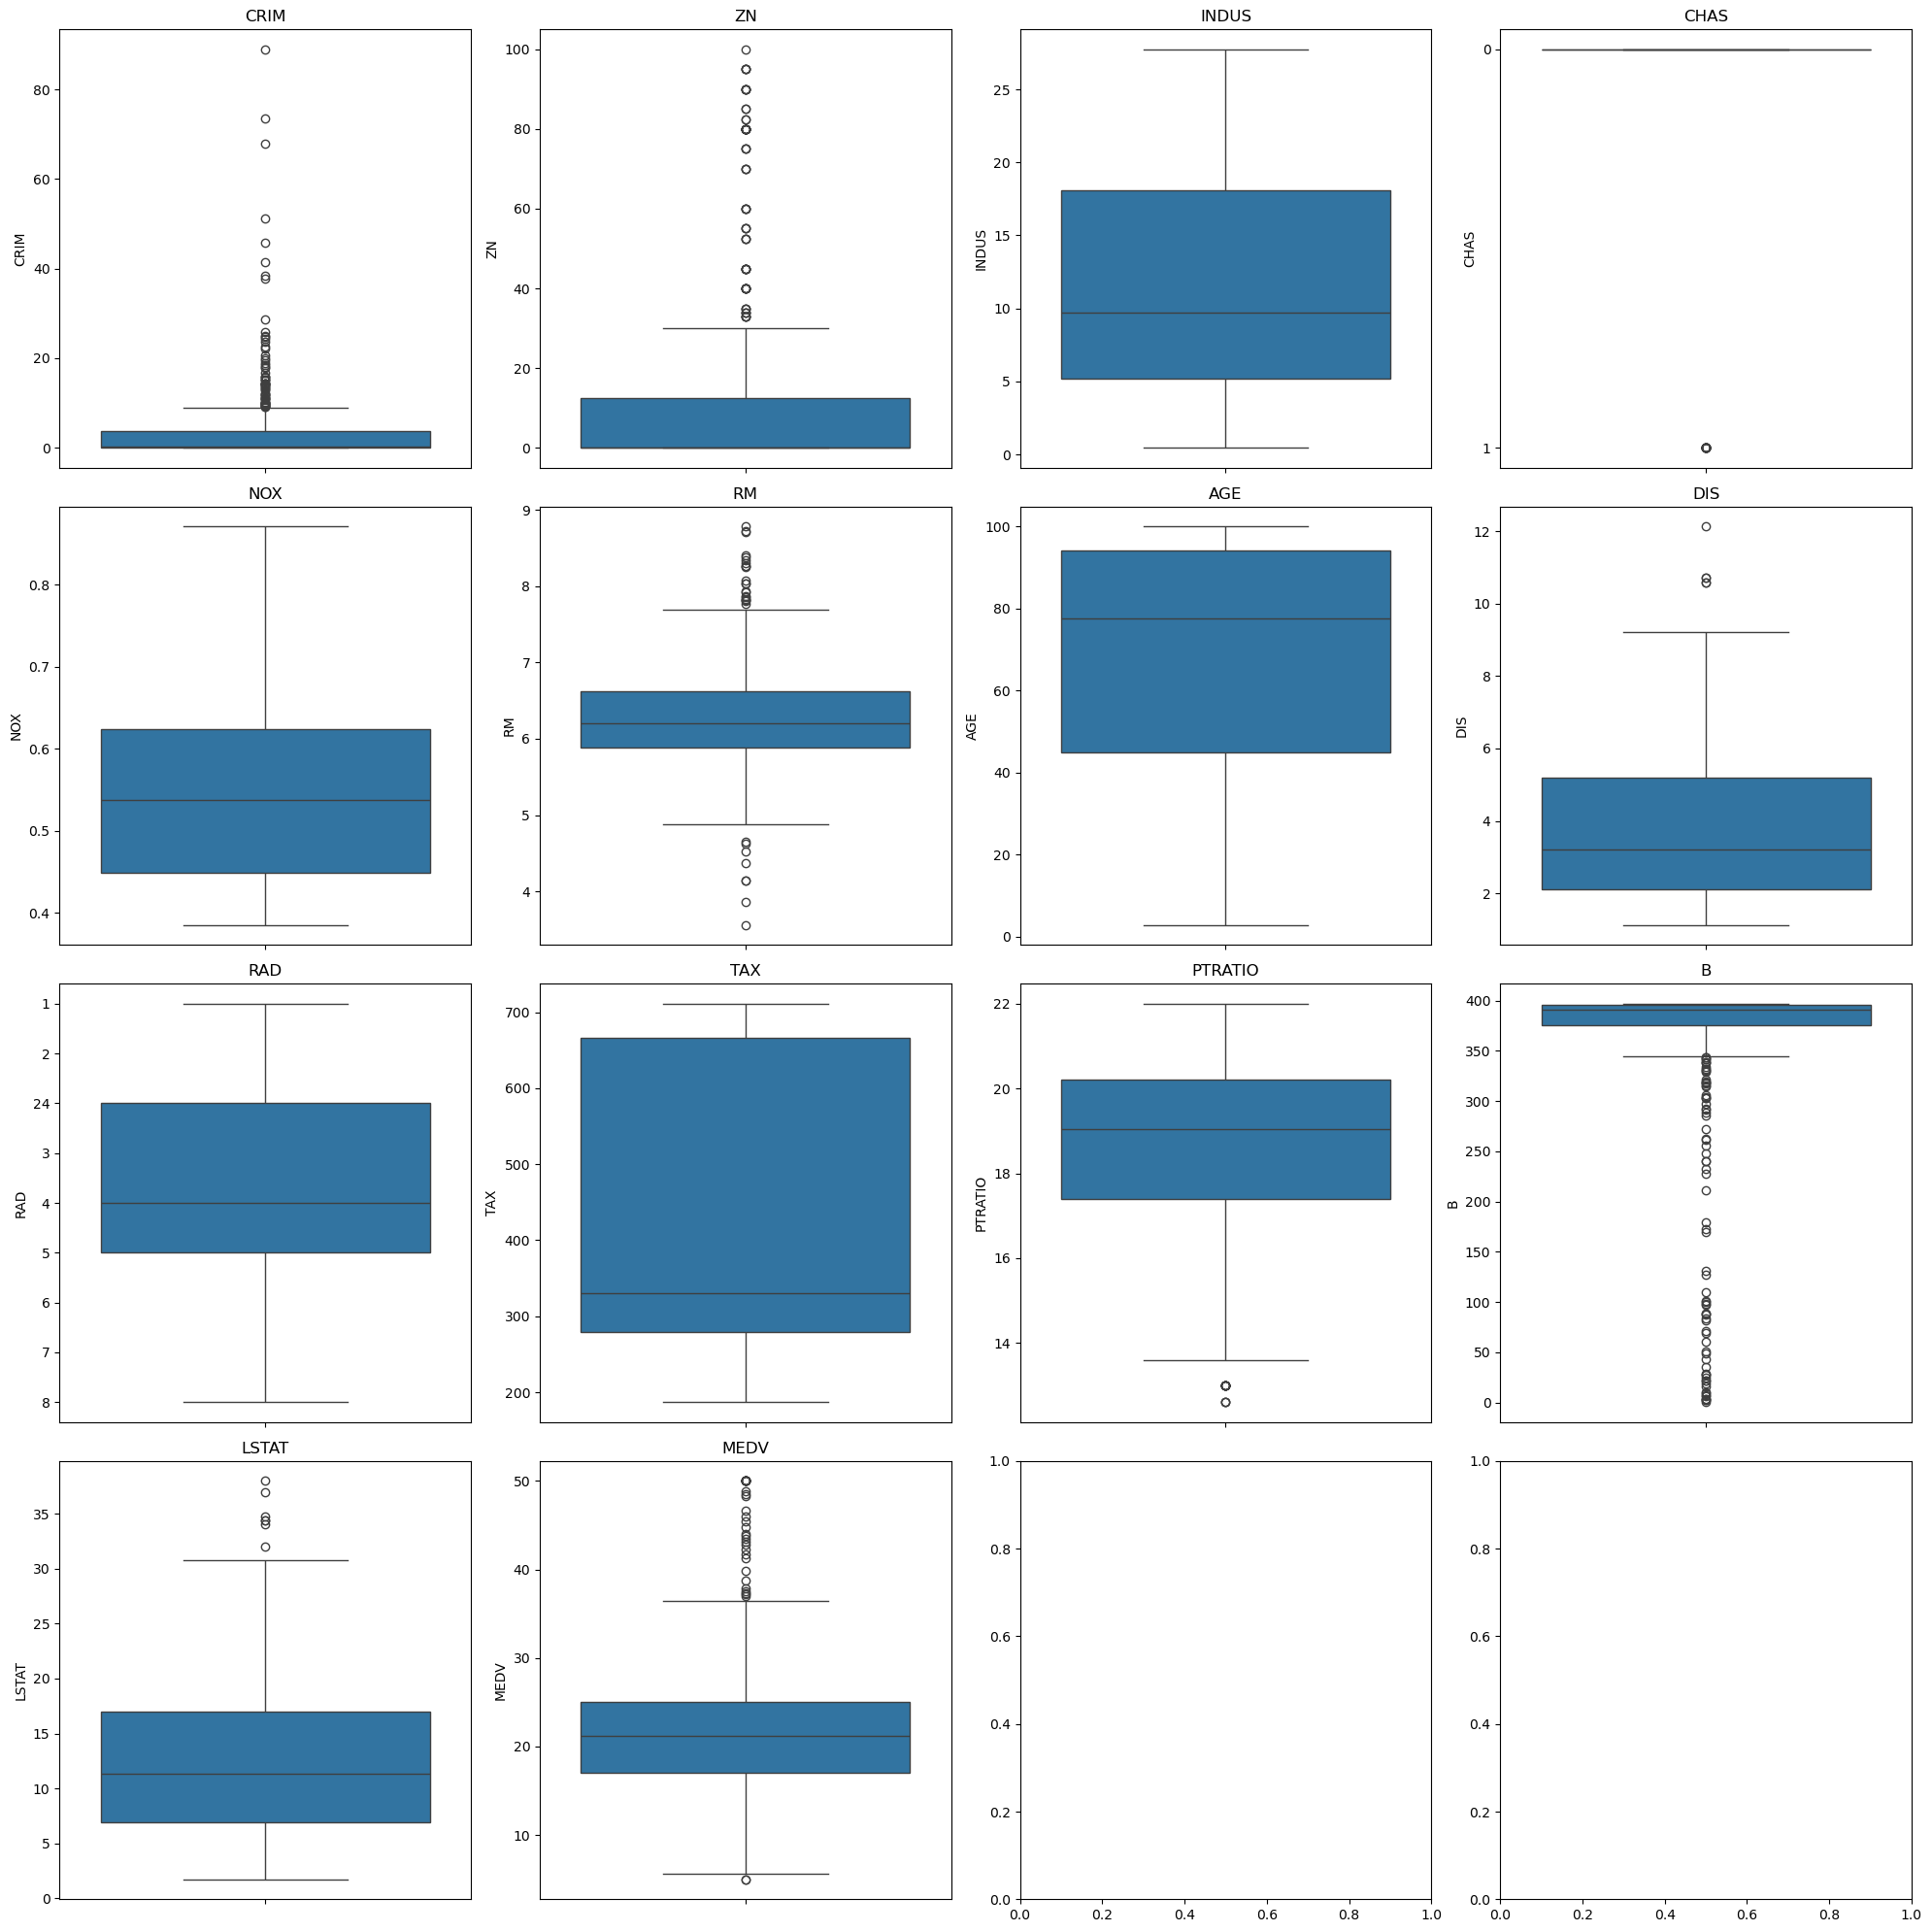

In [38]:
n_cols_per_row = 4
n_cols_total = len(df.columns)
n_rows = int(np.ceil(n_cols_total / n_cols_per_row))

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(5*n_cols_per_row, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# # Remove the empty slots
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Tensor transformation
- From pandas df to tensor

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
# Selected cols
cols = ["INDUS", "RM", "LSTAT", "NOX", "DIS"]
# X[cols].values : pandas -> numpy array
data_x = torch.from_numpy(X[cols].values).float()
data_y = torch.from_numpy(y.values).float()
data_x.shape

torch.Size([506, 5])

In [52]:
X = data_x
y = data_y.reshape(-1, 1)
print(X.shape, y.shape)

torch.Size([506, 5]) torch.Size([506, 1])


# 3. Model Selection

## Hyperparameter setting

In [56]:
learning_rate = 1e-3
n_epochs = 2000
print_interval = 100

In [ ]:
# Model
# X.size()
# output: torch.Size([506, 5])
# X.size(1)
# output: 5
# nn.Linear(input dimension, output dimension)
model = nn.Linear(X.size(-1), y.size(-1))

# We didnt set the batch size, so the system will identify the batch size as 506

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# 4.Model Training

In [59]:
for i in range(n_epochs):
    y_hat = model(X)
    # Mean Squared Error
    loss = F.mse_loss(y_hat, y)
    optimizer.zero_grad() # initialize optimizer's gradient
    loss.backward() # compute the gradient with respect to model parameters -> 역전파 계산
    
    optimizer.step() # model parameters (weight, bias) update

    if(i+1) % print_interval == 0:
        print(f'Epoch {i+1}: loss = {loss}')

Epoch 100: loss = 43.147193908691406
Epoch 200: loss = 36.870487213134766
Epoch 300: loss = 33.408077239990234
Epoch 400: loss = 31.456552505493164
Epoch 500: loss = 30.3564510345459
Epoch 600: loss = 29.736186981201172
Epoch 700: loss = 29.38633918762207
Epoch 800: loss = 29.18889045715332
Epoch 900: loss = 29.077327728271484
Epoch 1000: loss = 29.01416778564453
Epoch 1100: loss = 28.978286743164062
Epoch 1200: loss = 28.95777702331543
Epoch 1300: loss = 28.945940017700195
Epoch 1400: loss = 28.938976287841797
Epoch 1500: loss = 28.93476676940918
Epoch 1600: loss = 28.932109832763672
Epoch 1700: loss = 28.930330276489258
Epoch 1800: loss = 28.92903709411621
Epoch 1900: loss = 28.928035736083984
Epoch 2000: loss = 28.927175521850586


# 5. Evaluation

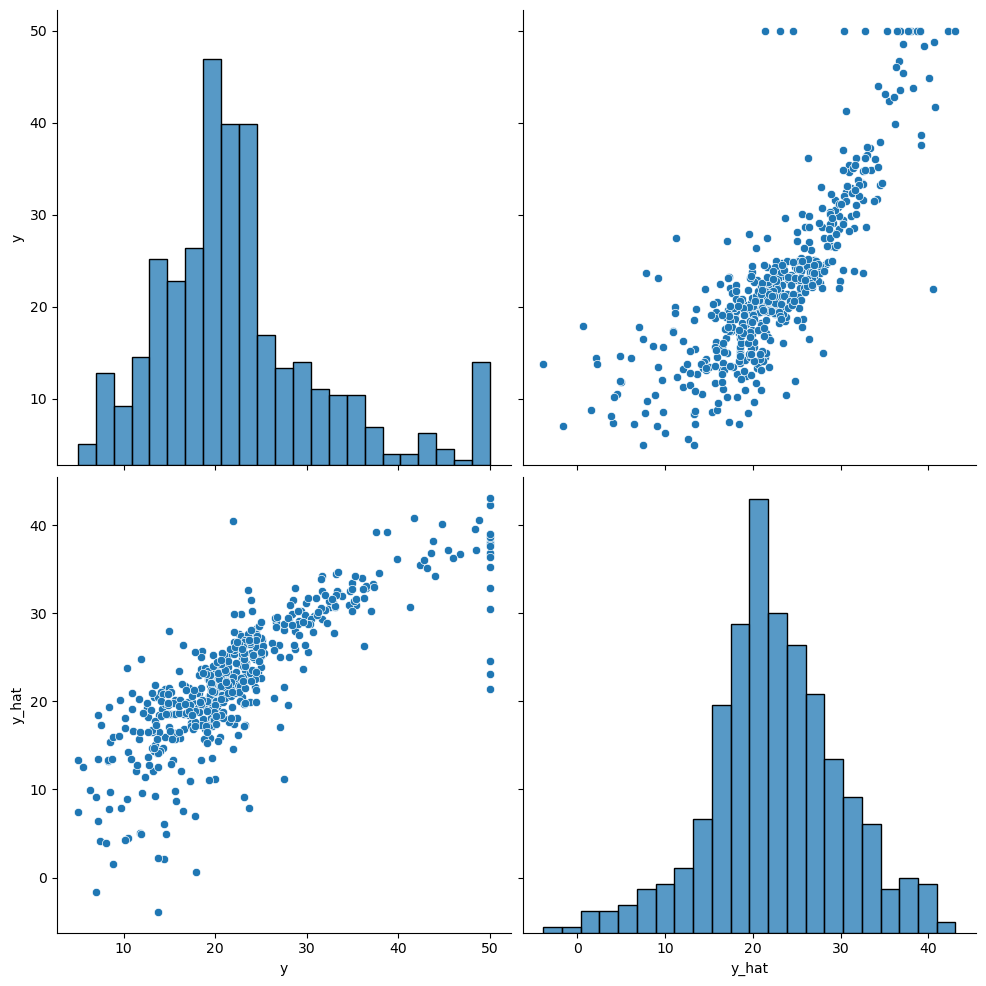

In [ ]:
# torch.cat([y, y_hat], dim = 1
# output: tensor in (N, 2)
# .detach_() : detach this tensor from computational graph,
# so that you can convert it to numpy array
# .numpy() : tensor to numpy array
df_result = pd.DataFrame(torch.cat([y, y_hat], dim = 1).detach_().numpy(), columns=['y', 'y_hat'])
sns.pairplot(df_result, height=5)
plt.show()